In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the raw data and drop columns not useful for the model
df = pd.read_csv('Churn_Modelling.csv')
df_ml = df.drop(columns=['RowNumber', 'Surname'])

# Keep CustomerId aside so we can return it later to Power BI
customer_ids = df_ml['CustomerId']
df_ml = df_ml.drop(columns=['CustomerId'])

print("Data Loaded. Shape:", df_ml.shape)

Data Loaded. Shape: (10000, 11)


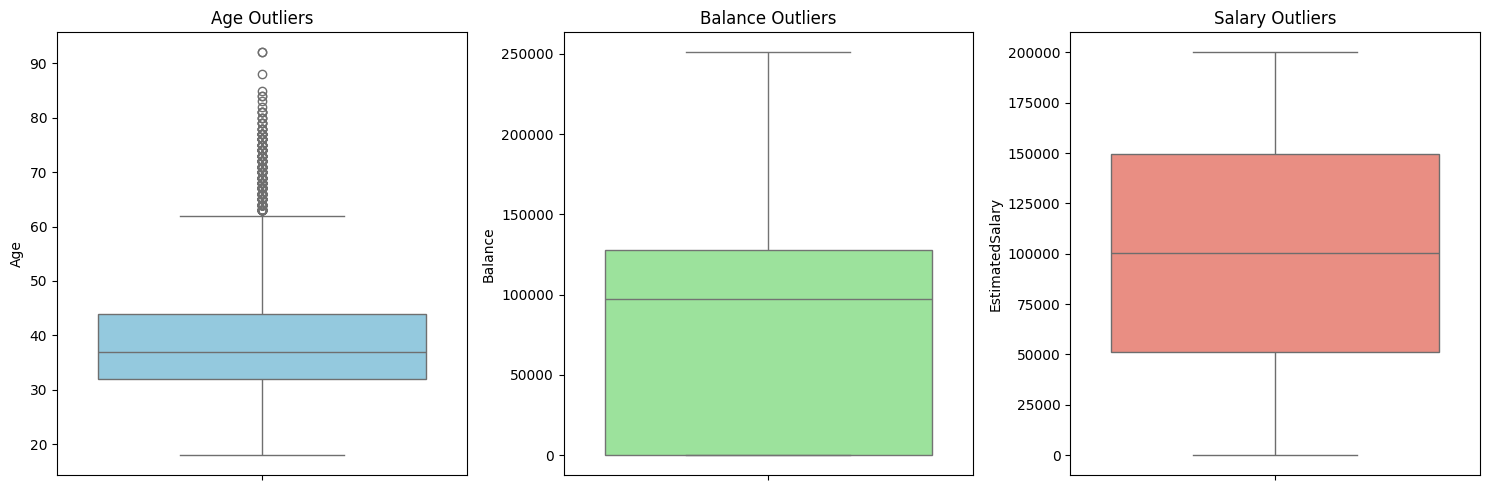

In [4]:
# Draw Boxplots for important numeric columns to visualize Outliers
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_ml['Age'], color='skyblue')
plt.title('Age Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_ml['Balance'], color='lightgreen')
plt.title('Balance Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_ml['EstimatedSalary'], color='salmon')
plt.title('Salary Outliers')

plt.tight_layout()
plt.show()


In [ ]:
# Convert text to numbers
df_ml['Gender'] = df_ml['Gender'].map({'Male': 1, 'Female': 0})
df_ml = pd.get_dummies(df_ml, columns=['Geography'], drop_first=True)

# Separate features (X) and target (y)
X = df_ml.drop(columns=['Exited'])
y = df_ml['Exited']

from sklearn.model_selection import train_test_split
# Split data (80% train - 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
df_ml.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False
